In [1]:
# Loading necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
df=pd.read_csv('/content/Titanic-Dataset.csv')

In [3]:
# Retreiving the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
# Finding the number of columns and rows
df.shape

(891, 12)

In [5]:
# Statistical Data of the dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Printing the 5 top most rows and columns
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# For finding missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [12]:
# For filling the numerical missing values
# Age
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
# For filling the categorical missing values
# Cabin
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [18]:
# For filling the categorical missing values
# Embark
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [23]:
# For identifying the duplicates
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [22]:
# Total number of duplicates
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='Age'>

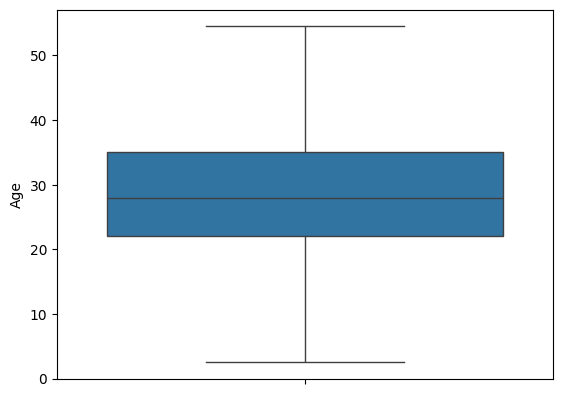

In [58]:
# Finding the outliers
sns.boxplot(df['Age'])

<Axes: ylabel='Fare'>

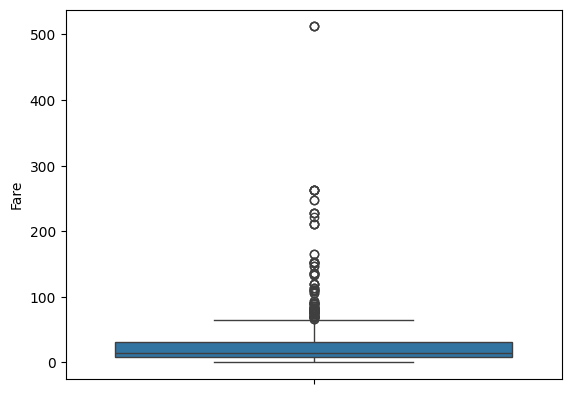

In [60]:
sns.boxplot(df['Fare'])

<Axes: ylabel='Embarked'>

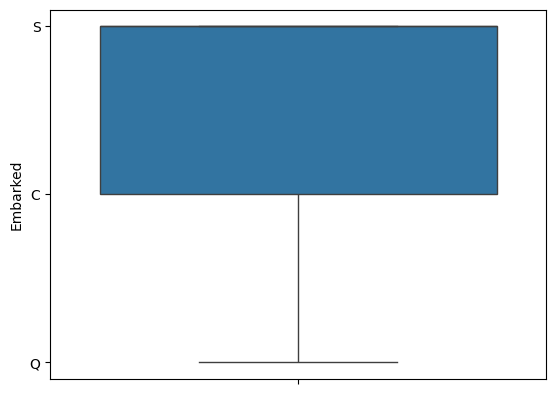

In [65]:
sns.boxplot(df['Embarked'])

In [66]:
# Q1
Q1 = df['Age'].quantile(0.25)
Q1 = df['Fare'].quantile(0.25)
Q1 = df['Embarked'].quantile(0.25)

In [67]:
# Q3
Q3 = df['Age'].quantile(0.75)
Q3 = df['Fare'].quantile(0.75)
Q3 = df['Embarked'].quantile(0.75)

In [31]:
# IQR
IQR = Q3-Q1

In [32]:
# Lower Limit
LL = Q1 - 1.5*IQR

In [33]:
# Upper Limit
UL = Q3 + 1.5*IQR

In [70]:
# Filling missing values
df['Age'] = df['Age'].clip(LL,UL)
df['Fare'] = df['Fare'].clip(LL,UL)
 # This is not suitable for categorical columns
 # This is not suitable for categorical columns

<Axes: ylabel='count'>

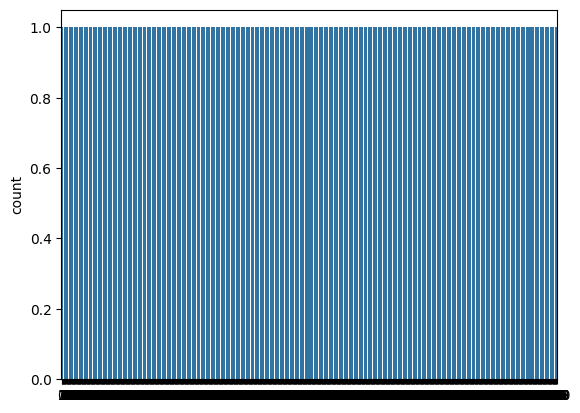

In [71]:
# Survival Distribution

sns.countplot(df['Survived'])

<Axes: xlabel='Age', ylabel='Count'>

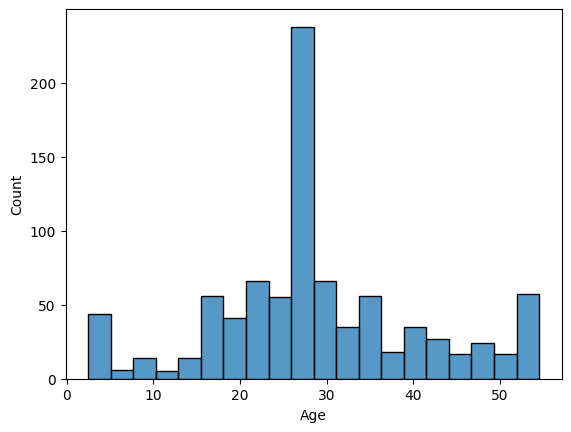

In [44]:
sns.histplot(df['Age'])

<Axes: xlabel='Sex', ylabel='count'>

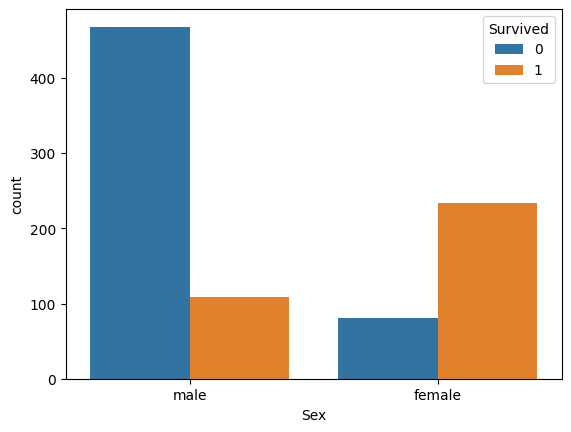

In [47]:
sns.countplot(x = df['Sex'], hue = df['Survived'])

<Axes: xlabel='Pclass', ylabel='count'>

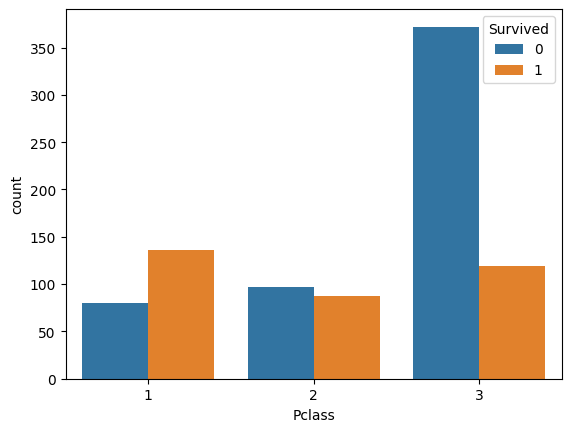

In [48]:
sns.countplot(x = df['Pclass'], hue = df['Survived'])

In [50]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [73]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [53]:
df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,1,1


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 137.3 KB


In [56]:
df.shape

(891, 14)

Key Insights:
1. The dataset had the missing values in the features 'Age', 'Cabin' and 'Embarked' where cleaning was required before the analysis
2. Missing values in 'Age' column was filled using Median where as 'Cabin' and 'Embarked' columns were filled using mode
3. No duplicate values were found, so no rows are removed.
4. Column 'Fare' had several outliers. Identified them using IQR method and handled them to reduce the effect of outliers
5. Survival rates differed across passenger groups, especially by 'Sex' and 'Passenger Class'. 2 new features 'FamilySize' and 'IsAlone' were also created to provide potentially useful info for a future model prediction.